In [5]:
import Coincidences as coinc
from pathlib import Path

In [2]:
#Demonstation notebook for the functions of Coincidences.py, including function to determine and correct time offsets between telescopes and match coincidences afterwards

module_253: 2 files found
  -> 20260115/start_2026-01-15T02-27-39Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  5477
Number of Events with package loss:  4  ( 0.07 %)


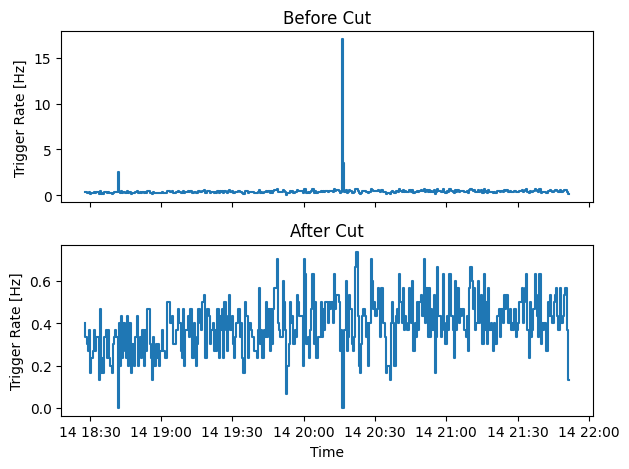

Rate spikes at:  DatetimeIndex(['2026-01-14 18:42:09.049767971-08:00',
               '2026-01-14 20:16:39.049767971-08:00',
               '2026-01-14 20:17:09.049767971-08:00'],
              dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  695  ( 12.7 %)
  -> 20260115/start_2026-01-15T05-55-39Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  4356
Number of Events with package loss:  0  ( 0.0 %)


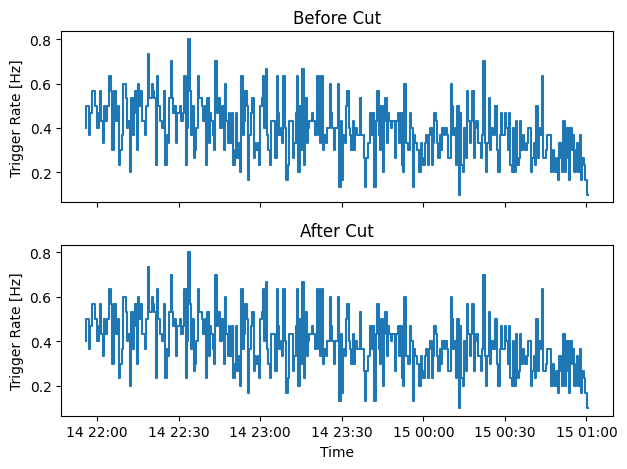

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
module_250: 2 files found
  -> 20260115/start_2026-01-15T02-27-40Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  6705
Number of Events with package loss:  7  ( 0.1 %)


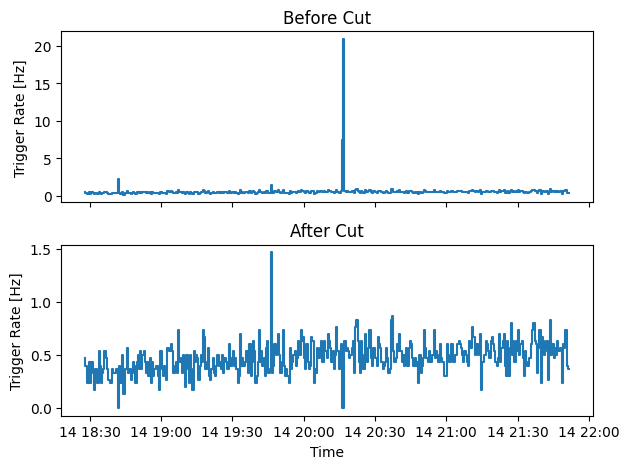

Rate spikes at:  DatetimeIndex(['2026-01-14 18:42:09.051706076-08:00',
               '2026-01-14 20:16:39.051706076-08:00',
               '2026-01-14 20:17:09.051706076-08:00'],
              dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  918  ( 13.71 %)
  -> 20260115/start_2026-01-15T05-55-40Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  5140
Number of Events with package loss:  0  ( 0.0 %)


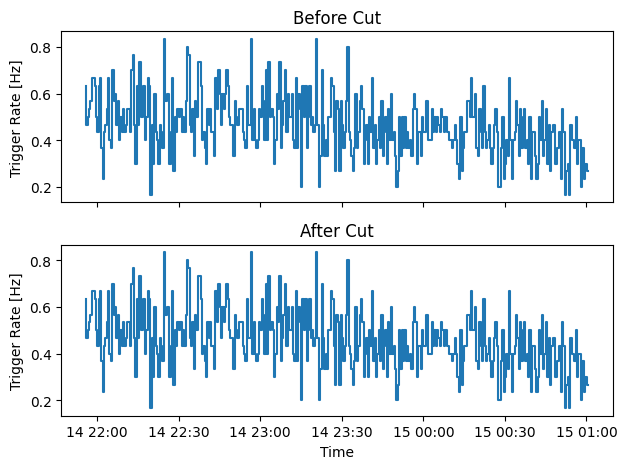

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
module_252: 2 files found
  -> 20260115/start_2026-01-15T02-27-40Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  7294
Number of Events with package loss:  1  ( 0.01 %)


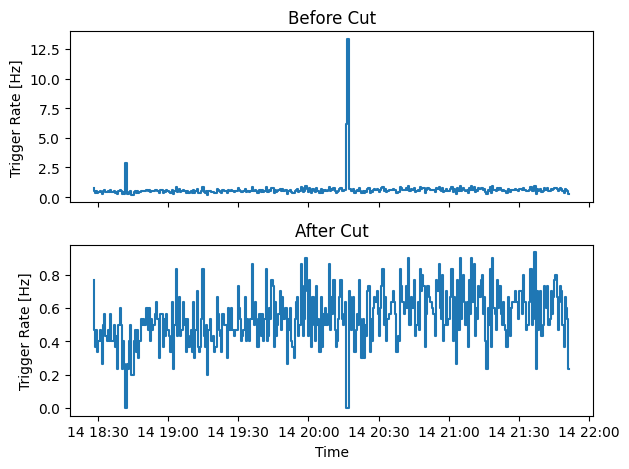

Rate spikes at:  DatetimeIndex(['2026-01-14 18:42:09.045408964-08:00',
               '2026-01-14 20:16:39.045408964-08:00',
               '2026-01-14 20:17:09.045408964-08:00'],
              dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  670  ( 9.19 %)
  -> 20260115/start_2026-01-15T05-55-40Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  5724
Number of Events with package loss:  0  ( 0.0 %)


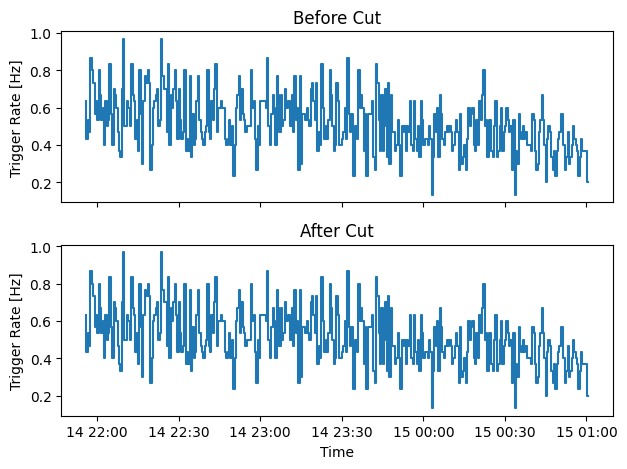

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
module_254: 2 files found
  -> 20260115/start_2026-01-15T02-27-39Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  2898
Number of Events with package loss:  9  ( 0.31 %)


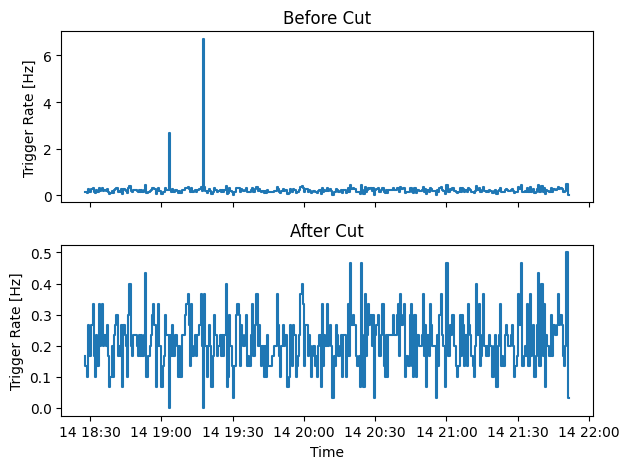

Rate spikes at:  DatetimeIndex(['2026-01-14 19:03:31.534018040-08:00', '2026-01-14 19:18:01.534018040-08:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  281  ( 9.73 %)
  -> 20260115/start_2026-01-15T05-55-39Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  2404
Number of Events with package loss:  0  ( 0.0 %)


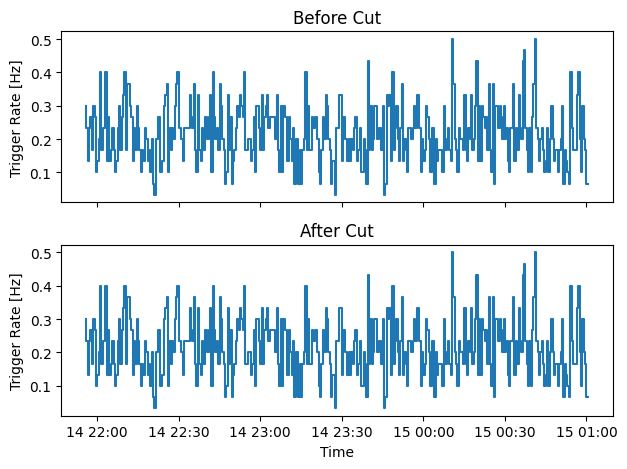

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)


In [14]:
#We have all pff files for one night, one source in a directory, e.g. 20260115/
#There could be multiple files for one telescope (e.g. before and mafter meridian flip)
#Every telescope has a module number which is part of file's name
#Assuming all pff files in the directory are not empty (could add condition to catch that later)
base_dir=Path("20260115/") #Path for data files
#corresponding module numbers for the telescopes
data_winter, timestamps_winter = coinc.load_telescope_tv("module_253", base_dir)
data_pti, timestamps_pti = coinc.load_telescope_tv("module_250", base_dir)
data_fern, timestamps_fern = coinc.load_telescope_tv("module_252", base_dir)
data_gattini, timestamps_gattini = coinc.load_telescope_tv("module_254", base_dir)
#Reads in all data files for corresponding telescope, runs pre_cleaning functions, combines multiple data files, returns data and timestamps

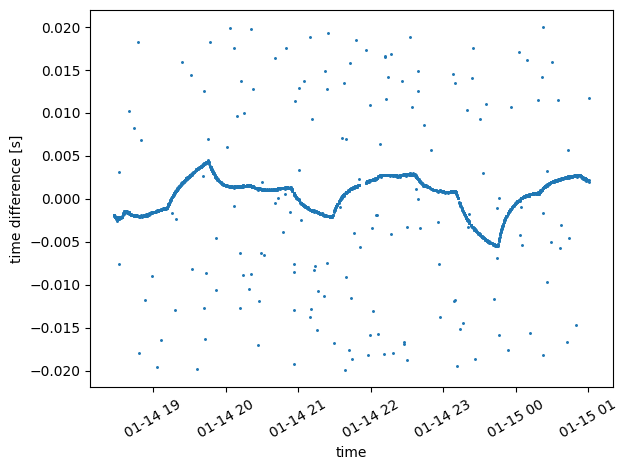

(array([1.76844407e+09, 1.76844407e+09, 1.76844408e+09, ...,
        1.76846761e+09, 1.76846762e+09, 1.76846762e+09], shape=(2703,)),
 array([1.76844407e+09, 1.76844407e+09, 1.76844408e+09, ...,
        1.76846761e+09, 1.76846762e+09, 1.76846762e+09], shape=(2703,)),
 array([-0.0019381 , -0.00199199, -0.00191402, ...,  0.002141  ,
         0.01178503,  0.00200415], shape=(2703,)))

In [8]:
#Taking Coincidences between Winter and PTI as an example:
#First check the timing offset by looking for coincidences within a large time window (default 20 ms), plotting timeing difference dt against timestamps of either telescope
coinc.time_offset(timestamps_winter,timestamps_pti,plotting=True)
#We see a continous bold line which marks the time difference of coincident events for winter and PTI
#However, it's not constant meaning the coincident events will show varrying time differences -> we won't see a clear peak in the dt distribution
#-> we need to make a time dependent correction for it

/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Offset: RMS=  0.00218 s, std= 0.00212 s
Corrected Offset: RMS=  0.0 s, std= 0.0 s


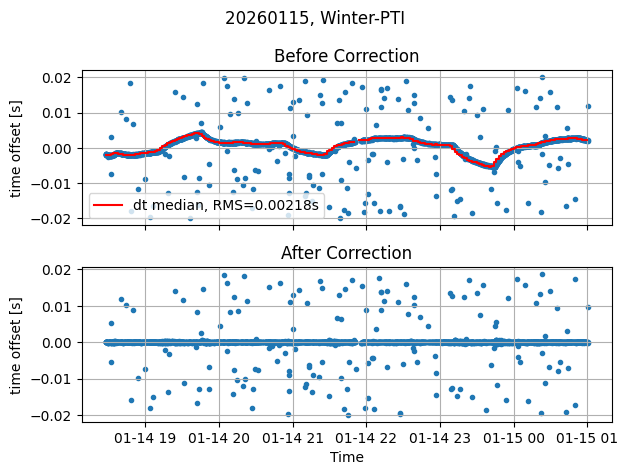

In [11]:
#We localize the bold line by taking the median of dt over a certain time window containing enough data point (default 120 s), see red line in top plot
#Subtracting median from all winter timestamps
#Making dt vs time plot again to check if time offset is now constant around 0
#Returning corrected timestamps for winter
timestamps_winter_corr=timestamps_winter_corr=coinc.correct_time(timestamps_winter,timestamps_pti,plot_name="Winter-PTI",base_dir=base_dir)
#We see that the red line fits the offset well -> bin_width of 120 s good enough, may need to adjust it for other nights
#Correction worked: Constant offset around 0, RMS=0

In [12]:
#Now we use the corrected winter timestamps to do the actual coincidence matching with a small time window (default 1ms, needs to be adjusted maybe)
#Input timestamps and data of both telescopes (use corrected timestamps for telescope 1/winter)
#Returns timestamps (local time, pd dataframe) and data of coincident events for both telescopes
time_coinc_winter, data_coinc_winter,time_coinc_pti,data_coint_pti=coinc.match_coinc(timestamps_winter_corr,data_winter,timestamps_pti,data_pti)

Number of events for telescope 1: 9134
Number of events for telescope 2: 10920
Number of coincident events within 0.001s: 2538 ( ~27.8% of all telescope 1 events and ~23.2% of all telescope 2 events.)
